In [1]:
import matplotlib as mpl
import seaborn as sns
import importlib

# Seaborn theme
sns.set_theme(
    style="ticks",        # "white", "whitegrid", "ticks", "darkgrid"
    context="paper",       # notebook, paper, talk, poster
    palette="deep"
)

# Your publication formatting
mpl.rcParams.update({

    # Fonts
    "font.family": "Arial",
    "font.size": 14,

    # Figure titles
    "figure.titlesize": 34,
    "figure.titleweight": "bold",

    # Axes titles/labels
    "axes.titlesize": 14,
    "axes.labelsize": 14,

    # Tick labels
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,

    # Legend
    "legend.fontsize": 10,
    "legend.title_fontsize": 12,

    # Lines & markers
    "lines.linewidth": 3,
    "lines.markersize": 8,

    # Axes
    "axes.linewidth": 2,

    # Ticks
    "xtick.major.size": 8,
    "ytick.major.size": 8,
    "xtick.major.width": 2,
    "ytick.major.width": 2,
    "xtick.minor.size": 4,
    "ytick.minor.size": 4,
    "xtick.minor.width": 1.5,
    "ytick.minor.width": 1.5,

    # Grid
    "grid.linewidth": 1,
    "grid.alpha": 0.3,

    # Export
    "figure.dpi": 150,
    "savefig.dpi": 600,

    # Editable vector graphics
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

# Manuscript Figure 2 — Rebinding shifts apparent affinity

Loads the rebinding on/off and rebinding-dose datasets. The replicate receptor layout is the statistical unit; shaded regions and error bars represent uncertainty across independent replicates.


In [2]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "analysis_tools":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from analysis_tools.manuscript_escape_analysis import (
    classical_occupancy, condition_statistics, discover_runs,
    load_receptor_summaries, occupancy_from_bound_time,
    replicate_survival_curves, save_figure, summarize_replicates,
)

SAVE_FIGURES = False
FIGURE_ROOT = PROJECT_ROOT / "analysis_tools" / "manuscript_panels"


## 1. Select data folders

Change only these paths after copying the cluster results.


In [3]:
ON_OFF_ROOT = "/Users/rynon/Library/CloudStorage/OneDrive-NorthwesternUniversity/PhD/Data/Agent-based simulations/261005_manuscript_fig2_rebinding_on_off"
DOSE_ROOT = "/Users/rynon/Library/CloudStorage/OneDrive-NorthwesternUniversity/PhD/Data/Agent-based simulations/261005_manuscript_fig2_rebinding_dose_response"

onoff_index = discover_runs(ON_OFF_ROOT)
dose_index = discover_runs(DOSE_ROOT)
display(onoff_index.groupby("condition_label").size().rename("replicates"))
display(dose_index.groupby("condition_label").size().rename("replicates"))


condition_label
moderate_R100nm__rebinding_off         8
moderate_R100nm__rebinding_on          8
planar__rebinding_off                  8
planar__rebinding_on                   8
semicircular_R49p5nm__rebinding_off    8
semicircular_R49p5nm__rebinding_on     8
Name: replicates, dtype: int64

condition_label
semicircular_R49p5nm__multiplier_0      6
semicircular_R49p5nm__multiplier_0p1    6
semicircular_R49p5nm__multiplier_0p3    6
semicircular_R49p5nm__multiplier_1      6
semicircular_R49p5nm__multiplier_3      6
Name: replicates, dtype: int64

## 2. Replicate summaries and quality control


In [6]:
onoff = summarize_replicates(onoff_index)
dose = summarize_replicates(dose_index)
qc_columns = ["condition_label", "replicate", "n_receptors", "n_trajectories", "censoring_fraction", "mean_bound_time_s", "mean_rebindings", "affinity_shift_fold"]
display(onoff[qc_columns])
print("Maximum censoring:", onoff.censoring_fraction.max())


,condition_label,replicate,n_receptors,n_trajectories,censoring_fraction,mean_bound_time_s,mean_rebindings,affinity_shift_fold
0,planar__rebinding_off,1,500,50000,0.00000,98.954899,0.000000,0.989549
1,planar__rebinding_off,2,500,50000,0.00000,99.476269,0.000000,0.994763
2,planar__rebinding_off,3,500,50000,0.00000,100.209155,0.000000,1.002092
3,planar__rebinding_off,4,500,50000,0.00000,100.367537,0.000000,1.003675
4,planar__rebinding_off,5,500,50000,0.00000,100.542692,0.000000,1.005427
5,planar__rebinding_off,6,500,50000,0.00000,100.120770,0.000000,1.001208
6,planar__rebinding_off,7,500,50000,0.00000,100.245465,0.000000,1.002455
7,planar__rebinding_off,8,500,50000,0.00000,100.056932,0.000000,1.000569
8,planar__rebinding_on,1,500,50000,0.00000,295.665196,1.976440,2.956652
9,planar__rebinding_on,2,500,50000,0.00000,298.809736,1.982860,2.988097


Maximum censoring: 5e-05


## 3. Figure 2A–B: survival and effective residence time


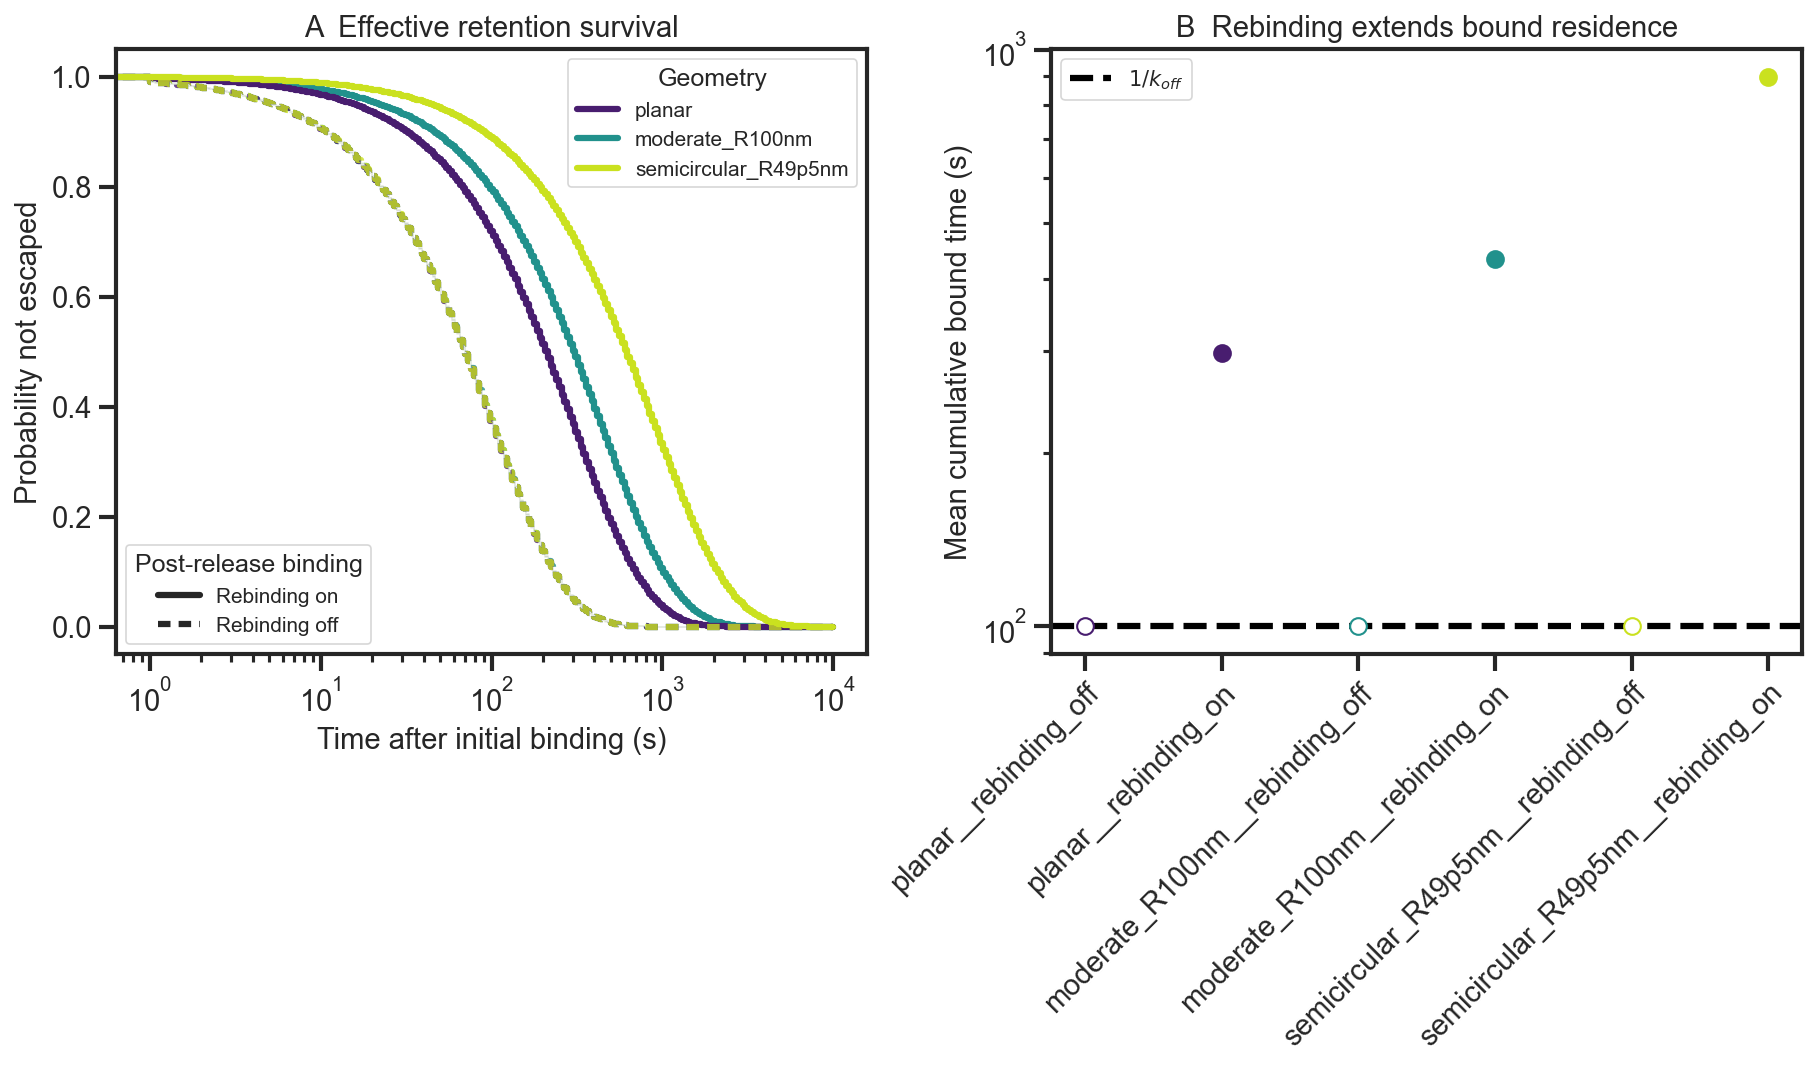

In [ ]:
grid = np.unique(np.r_[0, np.geomspace(1, onoff.max_time_s.max(), 250)])
survival = replicate_survival_curves(onoff_index, grid)
survival_summary = survival.groupby(["condition_label", "time_s"]).survival.agg(["mean", "sem"]).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 7), constrained_layout=True)
geometry_labels = list(dict.fromkeys(label.split("__")[0] for label in onoff.condition_label))
geometry_colors = dict(zip(geometry_labels, plt.cm.viridis(np.linspace(0.08, 0.92, len(geometry_labels)))))
for label, frame in survival_summary.groupby("condition_label", sort=False):
    frame = frame.sort_values("time_s")
    geometry_label = label.split("__")[0]
    rebinding_on = bool(onoff.loc[onoff.condition_label.eq(label), "rebinding_multiplier"].iloc[0] > 0)
    color = geometry_colors[geometry_label]
    linestyle = "-" if rebinding_on else (0, (2.0, 1.3))
    axes[0].step(frame.time_s, frame["mean"], where="post", color=color, linestyle=linestyle, alpha=1.0 if rebinding_on else 0.8)
    axes[0].fill_between(frame.time_s, np.clip(frame["mean"]-frame["sem"],0,1), np.clip(frame["mean"]+frame["sem"],0,1), step="post", color=color, alpha=.14 if rebinding_on else .06)
axes[0].set(xscale="log", xlabel="Time after initial binding (s)", ylabel="Probability not escaped", title="A  Effective retention survival")
geometry_legend = axes[0].legend(
    handles=[Line2D([0],[0], color=geometry_colors[label], label=label) for label in geometry_labels],
    title="Geometry", loc="upper right",
)
axes[0].add_artist(geometry_legend)
axes[0].legend(
    handles=[
        Line2D([0],[0], color="0.15", linestyle="-", label="Rebinding on"),
        Line2D([0],[0], color="0.15", linestyle=(0,(2.0,1.3)), label="Rebinding off"),
    ],
    title="Model", loc="lower left",
)

order = list(onoff.groupby("condition_index").condition_label.first().sort_index())
values = [onoff.loc[onoff.condition_label.eq(label), "mean_bound_time_s"] for label in order]
positions = np.arange(1, len(order)+1)
for position, label, data in zip(positions, order, values):
    geometry_label = label.split("__")[0]
    rebinding_on = bool(onoff.loc[onoff.condition_label.eq(label), "rebinding_multiplier"].iloc[0] > 0)
    color = geometry_colors[geometry_label]
    axes[1].errorbar(position, data.mean(), yerr=data.sem(), marker="o", markerfacecolor=color if rebinding_on else "white", markeredgecolor=color, color=color, linestyle="none", capsize=4)
axes[1].set_xticks(positions, order)
axes[1].axhline(1/onoff.k_off_s.iloc[0], color="black", ls="--", label=r"$1/k_{off}$")
axes[1].set(yscale="log", ylabel="Mean cumulative bound time (s)", title="B  Rebinding extends bound residence")
plt.setp(axes[1].get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
axes[1].legend()
if SAVE_FIGURES: save_figure(fig, FIGURE_ROOT, "figure2_AB_survival_residence")
plt.show()


## 4. Figure 2C–D: occupancy curves and apparent affinity shift


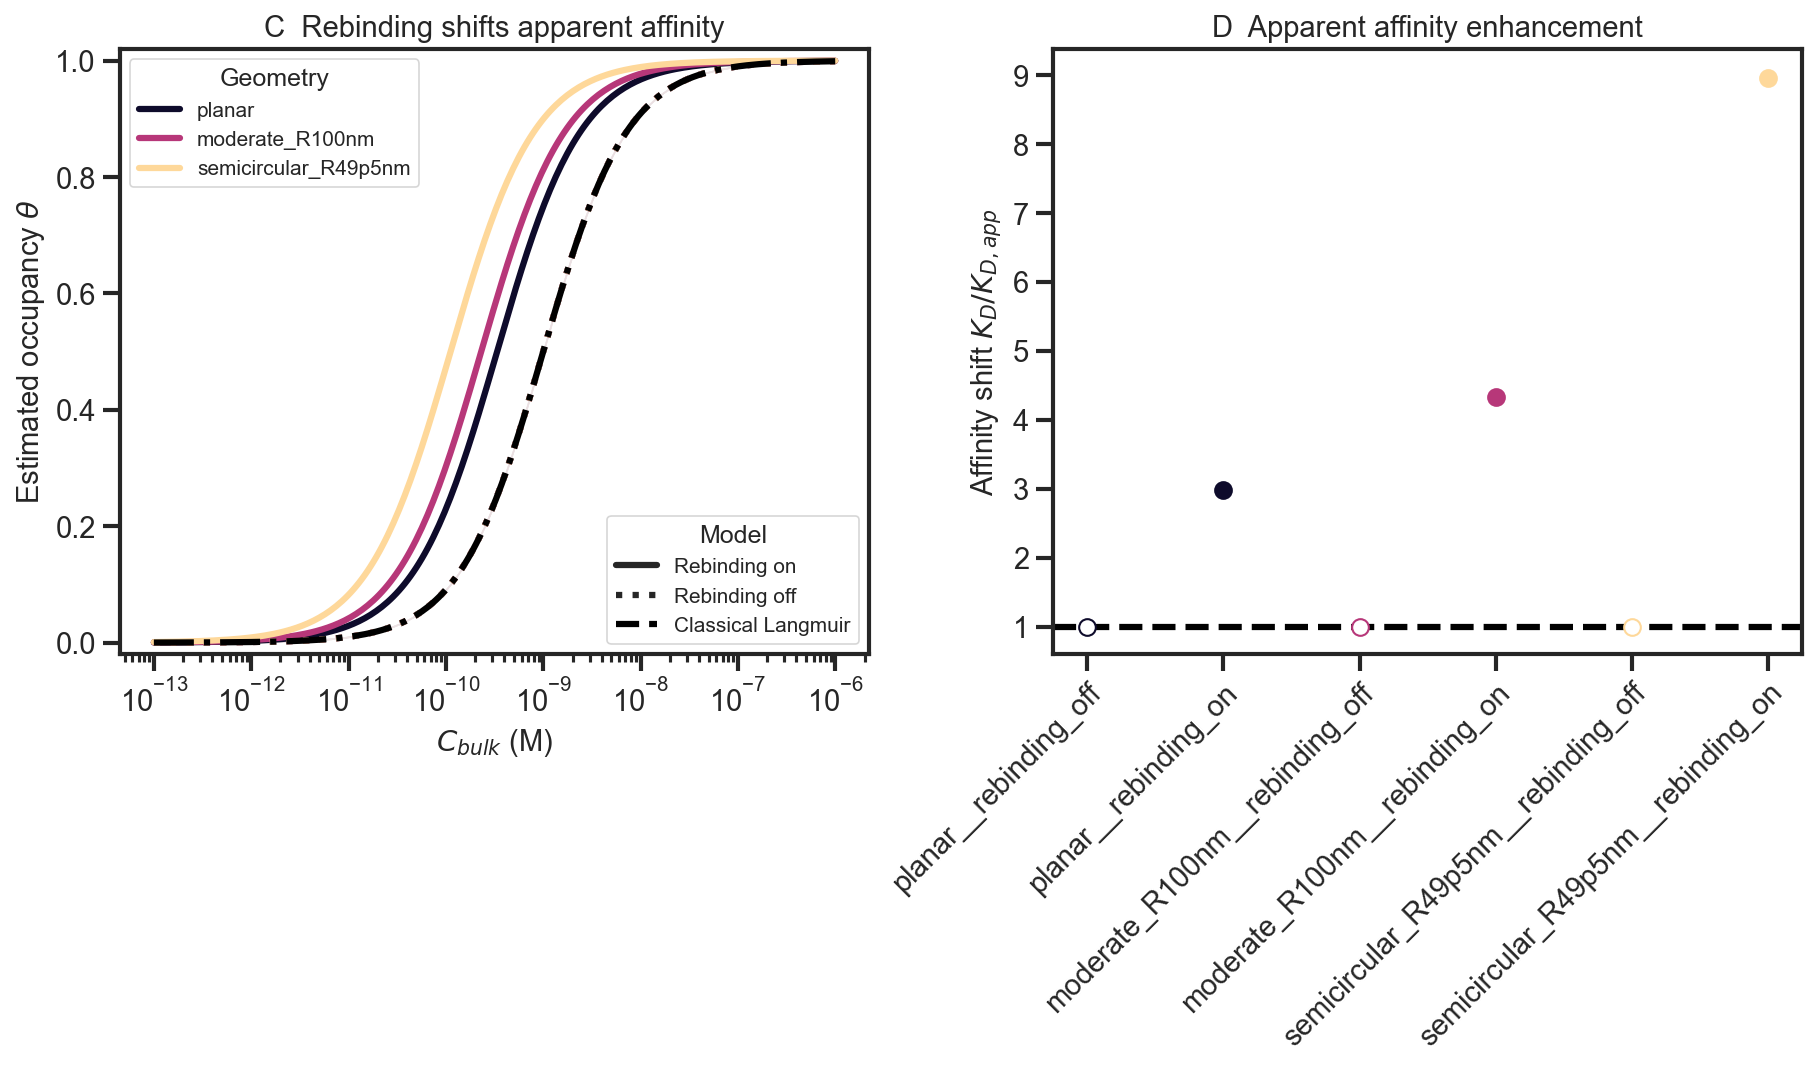

In [8]:
concentrations = np.logspace(-13, -6, 240)
fig, axes = plt.subplots(1, 2, figsize=(12, 7), constrained_layout=True)
geometry_labels = list(dict.fromkeys(label.split("__")[0] for label in onoff.condition_label))
geometry_colors = dict(zip(geometry_labels, plt.cm.magma(np.linspace(0.08, 0.92, len(geometry_labels)))))
for label, frame in onoff.groupby("condition_label", sort=False):
    geometry_label = label.split("__")[0]
    rebinding_on = bool(frame["rebinding_multiplier"].iloc[0] > 0)
    color = geometry_colors[geometry_label]
    linestyle = "-" if rebinding_on else ":"
    curves = np.vstack([occupancy_from_bound_time(row.mean_bound_time_s, row.k_on_M_inv_s, concentrations) for row in frame.itertuples()])
    axes[0].plot(concentrations, curves.mean(0), color=color, linestyle=linestyle)
    axes[0].fill_between(concentrations, np.clip(curves.mean(0)-curves.std(0,ddof=1)/np.sqrt(len(curves)),0,1), np.clip(curves.mean(0)+curves.std(0,ddof=1)/np.sqrt(len(curves)),0,1), color=color, alpha=.14 if rebinding_on else .06)
classical = classical_occupancy(onoff.k_on_M_inv_s.iloc[0], onoff.k_off_s.iloc[0], concentrations)
axes[0].plot(concentrations, classical, color="black", linestyle="-.")
axes[0].set(xscale="log", xlabel=r"$C_{bulk}$ (M)", ylabel=r"Estimated occupancy $\theta$", ylim=(-.02,1.02), title="C  Rebinding shifts apparent affinity")
geometry_legend = axes[0].legend(
    handles=[Line2D([0],[0], color=geometry_colors[label], label=label) for label in geometry_labels],
    title="Geometry", loc="upper left",
)
axes[0].add_artist(geometry_legend)
axes[0].legend(
    handles=[
        Line2D([0],[0], color="0.15", linestyle="-", label="Rebinding on"),
        Line2D([0],[0], color="0.15", linestyle=":", label="Rebinding off"),
        Line2D([0],[0], color="black", linestyle="--", label="Classical Langmuir"),
    ],
    title="Model", loc="lower right",
)

order = list(onoff.groupby("condition_index").condition_label.first().sort_index())
values = [onoff.loc[onoff.condition_label.eq(label), "affinity_shift_fold"] for label in order]
positions = np.arange(1, len(order)+1)
for position, label, data in zip(positions, order, values):
    geometry_label = label.split("__")[0]
    rebinding_on = bool(onoff.loc[onoff.condition_label.eq(label), "rebinding_multiplier"].iloc[0] > 0)
    color = geometry_colors[geometry_label]
    axes[1].errorbar(position, data.mean(), yerr=data.sem(), marker="o", markerfacecolor=color if rebinding_on else "white", markeredgecolor=color, color=color, linestyle="none", capsize=4)
axes[1].set_xticks(positions, order)
axes[1].axhline(1, color="black", ls="--")
axes[1].set(yscale="linear", ylabel=r"Affinity shift $K_D/K_{D,app}$", title="D  Apparent affinity enhancement")
plt.setp(axes[1].get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
if SAVE_FIGURES: save_figure(fig, FIGURE_ROOT, "figure2_CD_occupancy_affinity")
plt.show()


## 5. Rebinding-strength dose response


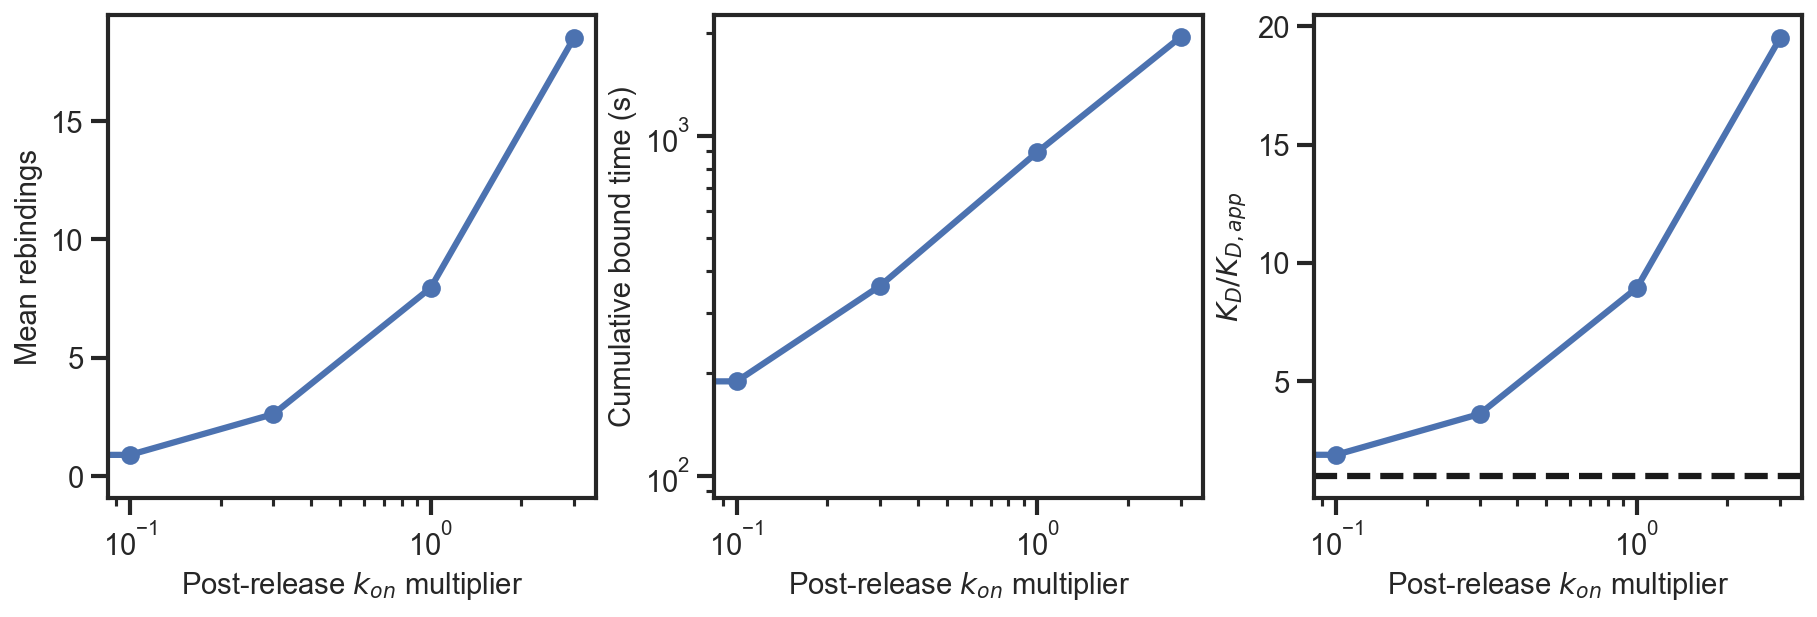

,rebinding_multiplier,mean_rebindings_mean,mean_rebindings_std,mean_rebindings_sem,mean_rebindings_count,mean_bound_time_s_mean,mean_bound_time_s_std,mean_bound_time_s_sem,mean_bound_time_s_count,affinity_shift_fold_mean,affinity_shift_fold_std,affinity_shift_fold_sem,affinity_shift_fold_count
0,0.0,0.000000,0.000000,0.000000,6,100.002860,0.486789,0.198731,6,1.000029,0.004868,0.001987,6
1,0.1,0.893260,0.008398,0.003428,6,189.441372,1.430262,0.583902,6,1.894414,0.014303,0.005839,6
2,0.3,2.617773,0.020927,0.008544,6,361.745742,2.354214,0.961104,6,3.617457,0.023542,0.009611,6
3,1.0,7.951617,0.060218,0.024584,6,894.702356,6.826768,2.787016,6,8.947024,0.068268,0.027870,6
4,3.0,18.529187,0.111560,0.045544,6,1951.833418,12.632850,5.157339,6,19.518334,0.126328,0.051573,6


In [9]:
dose_stats = condition_statistics(dose, ["rebinding_multiplier"], ["mean_rebindings", "mean_bound_time_s", "affinity_shift_fold"]).sort_values("rebinding_multiplier")
fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
for ax, metric, ylabel in zip(axes, ["mean_rebindings", "mean_bound_time_s", "affinity_shift_fold"], ["Mean rebindings", "Cumulative bound time (s)", r"$K_D/K_{D,app}$"]):
    ax.errorbar(dose_stats.rebinding_multiplier, dose_stats[f"{metric}_mean"], yerr=dose_stats[f"{metric}_sem"], marker="o", capsize=3)
    ax.set(xlabel=r"Post-release $k_{on}$ multiplier", ylabel=ylabel)
axes[1].set_yscale("log"); axes[2].set_yscale("linear"); axes[2].axhline(1,color="k",ls="--")
axes[0].set(xscale="log"); axes[1].set(xscale="log"); axes[2].set(xscale="log"); 
if SAVE_FIGURES: save_figure(fig, FIGURE_ROOT, "figure2_rebinding_dose_response")
plt.show()
display(dose_stats)


In [ ]:
OUTPUT = FIGURE_ROOT / "figure2_tables"
if SAVE_FIGURES:
    OUTPUT.mkdir(parents=True, exist_ok=True)
    onoff.to_csv(OUTPUT / "figure2_onoff_replicates.csv", index=False)
    dose.to_csv(OUTPUT / "figure2_dose_replicates.csv", index=False)
